## NGDS-Projekt - Gruppe H

Namen und E-Mail-Adressen der Gruppenmitglieder:

- Melchior von Weissenfluh vonwemel@students.zhaw.ch
- Nico Schellhaas schnic05@students.zhaw.ch

Zugeteilte Wetterstation: SMM

### Bibliotheken importieren und globale Parameter definieren

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

### 1. Daten importieren und filtern

Importiert die Daten (Strings und Zahlen getrennt), wählt die relevanten Spalten und Zeilen aus. Am Ende sollt ihr je ein Array für den Messzeitpunkt (in Tagen seit der ersten Messung, nicht als Datetime Objekte) und die gemessenen Wetterdaten für eure Wetterstation haben.

In [2]:
# Strings laden (Station + Datum)
strings = np.genfromtxt("Daten/Graubuenden.csv", delimiter=",", dtype=str, skip_header=1)

# Numerische Daten laden
numbers = np.genfromtxt("Daten/Graubuenden.csv", delimiter=",", skip_header=1)

# Zeit in Tagen
time_array = numbers[:, 6]
# Wetterdaten
weather_array = numbers[:, 2:6]
# Station auswählen
station_mask = strings[:, 0] == "SMM"
time_array = time_array[station_mask]
weather_array = weather_array[station_mask]

# Test Form
print(time_array.shape)
print(weather_array.shape)


(7384,)
(7384, 4)


### 2. Interpolation

Wir haben 15% der Zeilen in den Originaldaten gelöscht. Also gibt es nicht genau stündlich Messwerte.

Bestimmt eine Interpolationsfunktion für jede Messgrösse und interpoliert die Messreihen viertelstündlich (d.h. für jede Stunde vier Werte plus den Endpunkt am 1. Januar um 0:00).

Wählt die Art und den Grad der Interpolation so aus, dass die interpolierten Werte auch physikalisch sinnvoll sind.

In [3]:
# 1. Spalten aus deinem weather_array extrahieren
# WICHTIG: Prüfe in der 'Legende' der CSV, ob die Reihenfolge stimmt!
luftdruck = weather_array[:, 0]
temperatur = weather_array[:, 1]
regen = weather_array[:, 2]
sonne = weather_array[:, 3]

# 2. Ziel-Zeitachse definieren (Viertelstündlich)
# Wir nutzen dein 'time_array'
t_interp = np.arange(0, time_array[-1], 1/(24*4))
t_interp = np.append(t_interp, time_array[-1]) # Endpunkt hinzufügen

# 3. Interpolationsfunktionen erstellen
# Kubisch für glatte Verläufe, Linear für Regen/Sonne (wegen physikalischer Sinnhaftigkeit)
f_temp = interp1d(time_array, temperatur, kind='cubic')
f_druck = interp1d(time_array, luftdruck, kind='cubic')
f_regen = interp1d(time_array, regen, kind='linear')
f_sonne = interp1d(time_array, sonne, kind='linear')

# 4. Neue Werte berechnen
temp_interp = f_temp(t_interp)
druck_interp = f_druck(t_interp)
regen_interp = f_regen(t_interp)
sonne_interp = f_sonne(t_interp)

### 3. Daten und Interpolation darstellen und vergleichen 

Um die Interpolation zu überprüfen, stellt für alle Variablen jeweils die Daten und die Interpolationsfunktion zusammen grafisch dar.

Wählt dazu ein Zeitfenster von ein paar Tagen, in dem alle Variablen ein etwas interessantes Verhalten zeigen, d.h. es fällt Regen und die Sonne scheint.

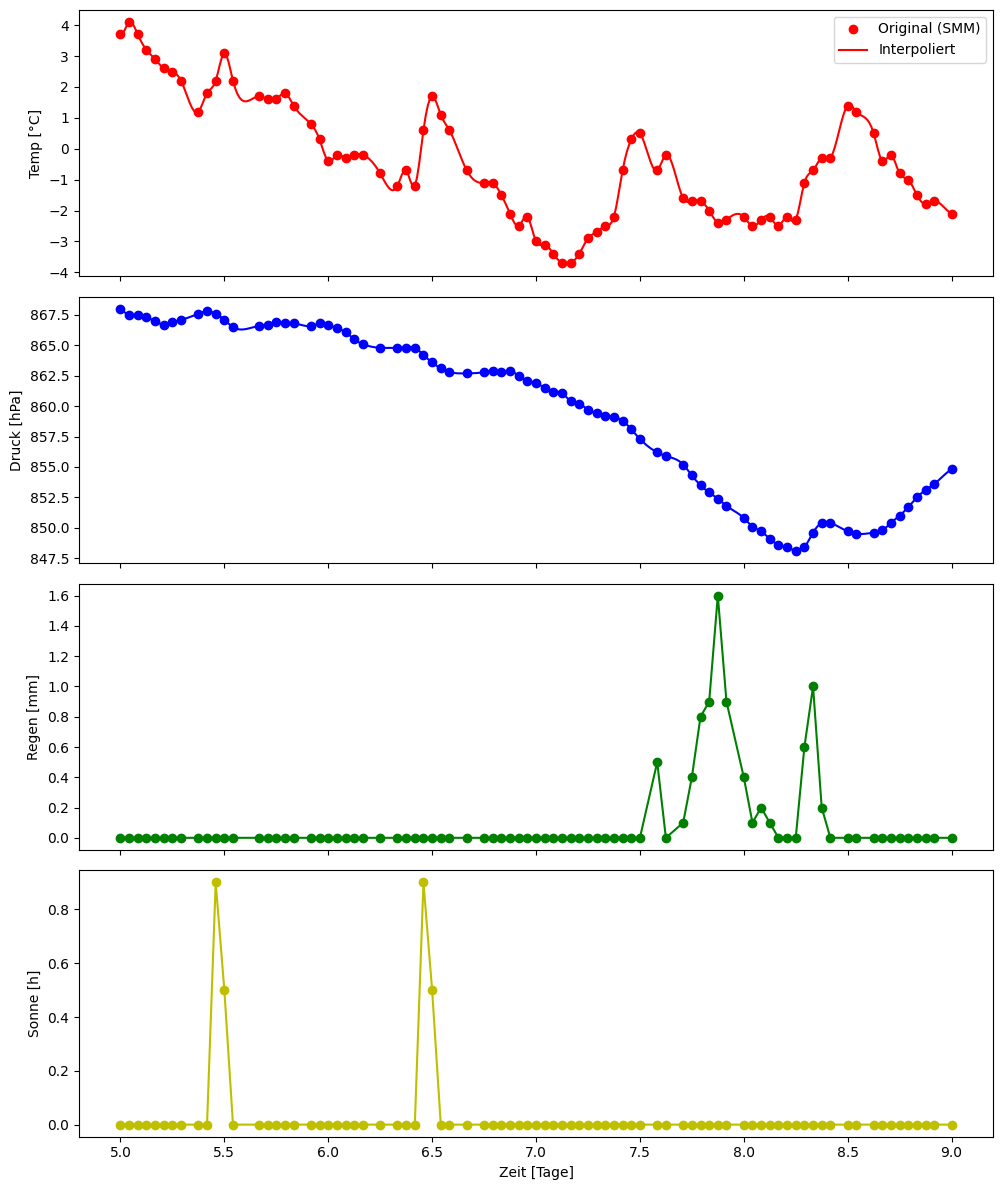

In [9]:
# Zeitfenster wählen (z.B. 3 Tage in der Mitte des Jahres)
t_start, t_end = 5, 9 

# Masken erstellen, um nur diesen Zeitraum zu plotten
m_orig = (time_array >= t_start) & (time_array <= t_end)
m_new = (t_interp >= t_start) & (t_interp <= t_end)

fig, axs = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

# Temperatur Plot
axs[0].plot(time_array[m_orig], temperatur[m_orig], 'ro', label='Original (SMM)')
axs[0].plot(t_interp[m_new], temp_interp[m_new], 'r-', label='Interpoliert')
axs[0].set_ylabel('Temp [°C]')
axs[0].legend()

# Luftdruck Plot
axs[1].plot(time_array[m_orig], luftdruck[m_orig], 'bo')
axs[1].plot(t_interp[m_new], druck_interp[m_new], 'b-')
axs[1].set_ylabel('Druck [hPa]')

# Regen Plot
axs[2].plot(time_array[m_orig], regen[m_orig], 'go')
axs[2].plot(t_interp[m_new], regen_interp[m_new], 'g-')
axs[2].set_ylabel('Regen [mm]')

# Sonne Plot
axs[3].plot(time_array[m_orig], sonne[m_orig], 'yo')
axs[3].plot(t_interp[m_new], sonne_interp[m_new], 'y-')
axs[3].set_ylabel('Sonne [h]')
axs[3].set_xlabel('Zeit [Tage]')

plt.tight_layout()
plt.show()

### 4. Nullstellen der Temperatur bestimmen

Wählt einen Zeitraum von ca. einer Woche, in der die Temperatur um Null herum schwankt. 

Bestimmt die Zeitpunkte, an denen die Temperatur den Wert Null hat. Nutzt dazu die Interpolationsfunktion der Temperatur aus Schritt 2 und nicht die Originaldaten.

Stellt die Temperatur und die Nullstellen zusammen grafisch dar.

Alternativ (und ein wenig schwieriger) könnt ihr auch einen Zeitraum wählen, in der die Temperatur hohe Werte erreicht. Bestimmt dann die Zeitpunkte, an denen die Temperatur einen bestimmten Hitzewert überschreitet, z.B. 30 Grad.

Tage mit Regen: [7.58333333 7.70833333 7.75       7.79166667 7.83333333 7.875
 7.91666667 8.         8.04166667 8.08333333]


### 5. Grosse Schwankungen in Temperatur oder Luftdruck finden

Betrachtet entweder die Temperatur oder den Luftdruck übers ganze Jahr. Berechnet die Ableitung der gewählten Variable und stellt diese auch dar, um einen Zeitraum von ca. 1 Woche mit grossen Schwankungen zu finden. Nutzt dazu die Interpolationsfunktion der Temperatur aus Schritt 2 und nicht die Originaldaten.

In der gewählten Woche mit grossen Schwankungen sollen nun die Zeitpunkte bestimmt werden, zu denen die Temperatur bzw. der Luftdruck am stärksten steigt bzw. fällt, also das Maximum und das Minimum der Ableitung.

Um das Maximum/Minimum eines Arrays zu finden, könnt ihr die Funktionen [`np.argmax`](https://numpy.org/doc/stable//reference/generated/numpy.argmax.htm) und [`np.argmin`](https://numpy.org/doc/stable//reference/generated/numpy.argmin.html) verwenden. 

### 6. Mittelwerte berechnen

Wählt eine der Messgrössen aus und berechnet den Mittelwert über das ganze Jahr und den Mittelwert pro Monat (1 Monat = 1/12 des Jahres). Nutzt dazu die Interpolationsfunktion der Temperatur aus Schritt 2 und nicht die Originaldaten.

Stellt die eigentliche Variable und die Mittelwerte zusammen grafisch dar.

Die Mittelung soll mithilfe der Integration über die Interpolationsfunktion aus Schritt 2 berechnet werden.

Bei der Integration kann es Warnungen geben, da die Interpolationsfunktionen teils stark schwanken. Es kann hilfreich sein, mit dem Parameter `limit` die Anzahl Subintervalle zu erhöhen. Probiert aus, ab wann sich das Resultat nicht mehr gross ändert.

*Empfehlungen:* 
- Implementiert dies zuerst für die Temperatur, da diese am einfachsten zu interpretieren ist. Dann könnt ihr immer noch die anderen Messgrössen betrachten.
- Beginnt mit dem Mittelwert über das ganze Jahr, dann verallgemeinert für ein beliebiges Zeitintervall und iteriert schliesslich über die Monate.

### 7. Glättung (Gleitendes Mittel) bestimmen

Nehmt die gleiche Messgrösse wie in Schritt 6 und berechnet das gleitende Mittel über das ganze Jahr. Dazu soll die Faltung mit einer symmetrischen Rechteckfunktion verwendet werden. Die Fensterbreite (Breite des Rechtecks) soll ein Parameter sein, den ihr variieren könnt.

Stellt die Messgrösse und das gleitende Mittel mit Fensterbreite = 7 Tage zusammen dar. Optional könnt ihr dazu auch noch das gleitende Mittel mit Fensterbreite = 14 und/oder 28 Tage darstellen.

Entscheidet selbst, ob ihr die kontinuierliche Faltung (Integration) oder die diskrete Faltung (Matrixmultiplikation) benutzt. 

*Vorsicht:* Die kontinuierliche Faltung (Integration) ist rechenintensiv. Berechnet also zuerst das gleitende Mittel an wenigen Zeitpunkten über das ganze Jahr, z.B. 100, und erhöht dann die Anzahl Zeitpunkte vorsichtig.

### Zusammenfassung

### Reflexion

Mitglied 1:
- Was hat gut funktioniert?
- Was hat nicht gut funktioniert?
- Was würdest du beim nächsten Mal anders machen?
- Was hast du gelernt?
- Was war die grösste Herausforderung?
- usw.


Mitglied 2:
- Was hat gut funktioniert?
- Was hat nicht gut funktioniert?
- Was würdest du beim nächsten Mal anders machen?
- Was hast du gelernt?
- Was war die grösste Herausforderung?
- usw.

Mitglied 3:
- Was hat gut funktioniert?
- Was hat nicht gut funktioniert?
- Was würdest du beim nächsten Mal anders machen?
- Was hast du gelernt?
- Was war die grösste Herausforderung?
- usw.